# ***Crop Yield Analysis Using Python***

**Importing Libraries & Loading Dataset**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
df_orginal=pd.read_csv("/content/yield_df.csv")

In [3]:
df=df_orginal.copy()

**Data Cleaning & Dataset**

In [4]:
df.head(10)

,Unnamed: 0,Area,Crop,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485,121.0,16.37
5,5,Albania,Wheat,1990,30197,1485,121.0,16.37
6,6,Albania,Maize,1991,29068,1485,121.0,15.36
7,7,Albania,Potatoes,1991,77818,1485,121.0,15.36
8,8,Albania,"Rice, paddy",1991,28538,1485,121.0,15.36
9,9,Albania,Sorghum,1991,6667,1485,121.0,15.36


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
Area,0
Crop,0
Year,0
hg/ha_yield,0
average_rain_fall_mm_per_year,0
pesticides_tonnes,0
avg_temp,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Crop                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  int64  
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(2), int64(4), object(2)
memory usage: 1.7+ MB


In [7]:
df.drop('Unnamed: 0', axis=1, inplace=True)

This dataset is already cleaned so we can directly perform EDA

# **Which crop appears most frequently?**

**Basic Exploratory Data Analysis**

In [8]:

df['Crop'].value_counts().sort_values(ascending=False)

,count
Crop,
Potatoes,4276
Maize,4121
Wheat,3857
"Rice, paddy",3388
Soybeans,3223
Sorghum,3039
Sweet potatoes,2890
Cassava,2045
Yams,847


INSIGHT : The Crop Potatoes appears more frequently with count 4276

# Which countries have the most records?

In [9]:
df['Area'].value_counts().head(10)

,count
Area,
India,4048
Brazil,2277
Mexico,1472
Pakistan,1449
Australia,966
Japan,966
Indonesia,828
South Africa,644
Turkey,625


INSIGHT : In the Dataset used India has more records with count 4048

# Which crop has the highest average yield?

In [10]:
df.groupby('Crop')['hg/ha_yield'].mean().idxmax()

'Potatoes'

INSIGHT : As the Potatoe Crops are more, it also has the Highest Average Yield

# Which countries produce the highest average yield?

In [11]:
df.groupby('Area')['hg/ha_yield'].mean().idxmax()

'United Kingdom'

INSIGHT : The United Kingdom produces highest average yield even when India appears more in the Dataset

# How has crop yield changed over years?

In [12]:
Year_yield=df.groupby('Year')['hg/ha_yield'].mean()

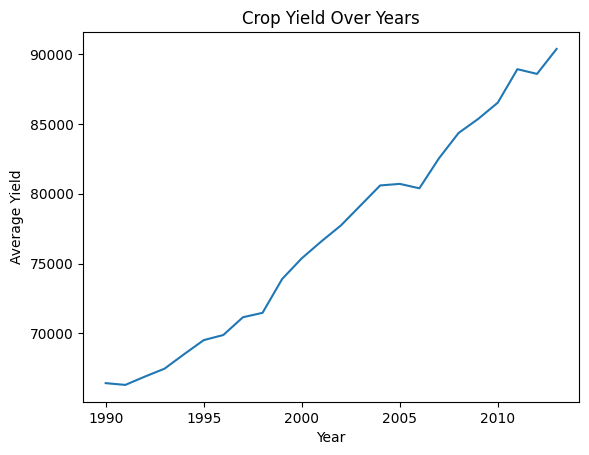

In [13]:
sns.lineplot(x=Year_yield.index, y=Year_yield.values)
plt.xlabel('Year')
plt.ylabel('Average Yield')
plt.title('Crop Yield Over Years')
plt.show()

INSIGHT : Crop yield has significantly increased over Years. From the Year 1990 to 1995 there's no significant growth but from the year 1998 there's a noticable growth overtime.

# Which crops need the highest pesticides?

In [14]:
df.groupby('Crop')['pesticides_tonnes'].mean().sort_values(ascending=False)

,pesticides_tonnes
Crop,
Yams,71945.976068
Cassava,44181.307457
Soybeans,40752.554896
Sweet potatoes,39448.289848
"Rice, paddy",36942.215995
Sorghum,36742.457529
Wheat,35453.212930
Maize,32765.983322
Potatoes,32152.516104


INSIGHT : Crops like Yams, Cassava, Soybeans need highest pesticides with over 40,000 tonnes.

# Does temperature affect crop yield?

<Axes: xlabel='avg_temp', ylabel='hg/ha_yield'>

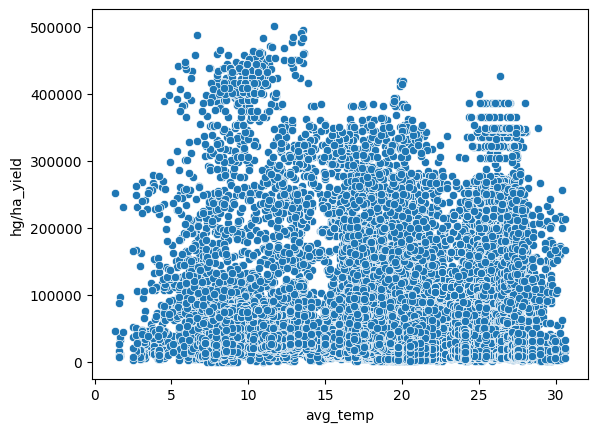

In [15]:
sns.scatterplot(x='avg_temp', y='hg/ha_yield',data=df)

Insight : The graph shows that temperature does have some impact on crop yield, but the relationship is not very clear or consistent. Some crops perform well at certain temperature ranges, while others show varying productivity levels.

# Which crop has the highest average temperature?

/tmp/ipykernel_6998/2042464597.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=high_temp.index,y=high_temp.values, palette=['blue','yellow'])
/tmp/ipykernel_6998/2042464597.py:2: UserWarning: 
The palette list has fewer values (2) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=high_temp.index,y=high_temp.values, palette=['blue','yellow'])


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Plantains and others'),
  Text(1, 0, 'Cassava'),
  Text(2, 0, 'Yams'),
  Text(3, 0, 'Sweet potatoes'),
  Text(4, 0, 'Sorghum'),
  Text(5, 0, 'Rice, paddy'),
  Text(6, 0, 'Maize'),
  Text(7, 0, 'Soybeans'),
  Text(8, 0, 'Potatoes'),
  Text(9, 0, 'Wheat')])

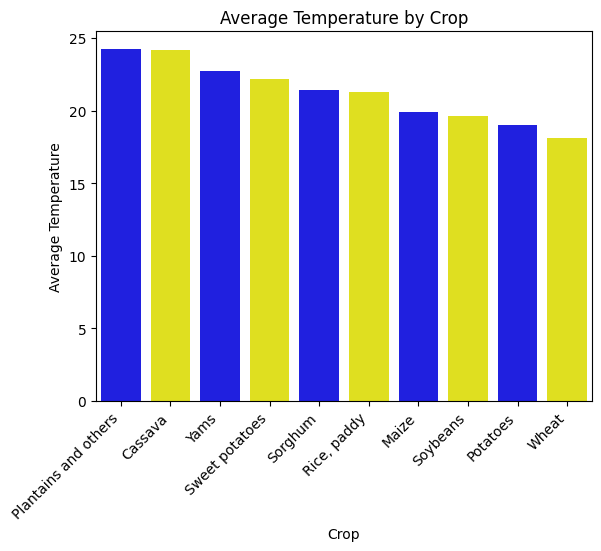

In [16]:
high_temp=df.groupby('Crop')['avg_temp'].mean().sort_values(ascending=False)
sns.barplot(x=high_temp.index,y=high_temp.values, palette=['blue','yellow'])
plt.title('Average Temperature by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Temperature')
plt.xticks(rotation=45, ha='right')

Insight : Through this bar graph it's known most of the crops has temperature above 20 but crops like Plantains, Cassava have more temperature than others

# Distribution of crop yield

Text(0.5, 1.0, 'Yield Distribution')

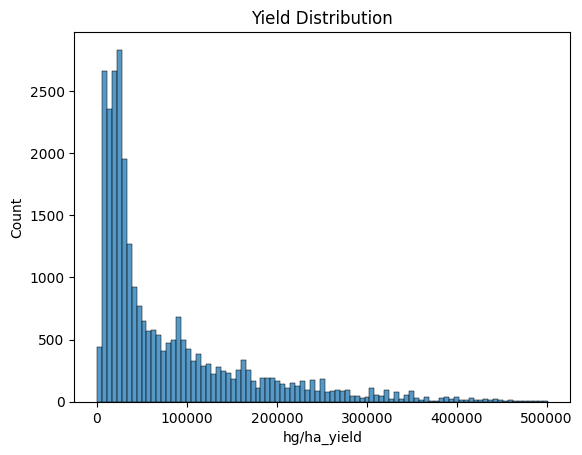

In [17]:
sns.histplot(df['hg/ha_yield'])

plt.title('Yield Distribution')

Insight : Most crop yield values are concentrated in the lower range, while only a few observations show very high productivity levels.

# Which crop has the highest maximum yield?

In [18]:
df.groupby('Crop')['hg/ha_yield'].max().sort_values(ascending=False)

,hg/ha_yield
Crop,
Potatoes,501412
Plantains and others,418505
Sweet potatoes,400000
Cassava,385818
Yams,250000
Maize,207556
Sorghum,206000
"Rice, paddy",103895
Wheat,99387


INSIGHT : Potatoes are leading throughout. Crop Potates has the Highest maximum yield.

# Compare average yield of top 5 crops

/tmp/ipykernel_6998/937650580.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crops.index,y=crops.values, palette=['yellow','orange','pink','brown','blue'])


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Potatoes'),
  Text(1, 0, 'Cassava'),
  Text(2, 0, 'Sweet potatoes'),
  Text(3, 0, 'Yams'),
  Text(4, 0, 'Plantains and others')])

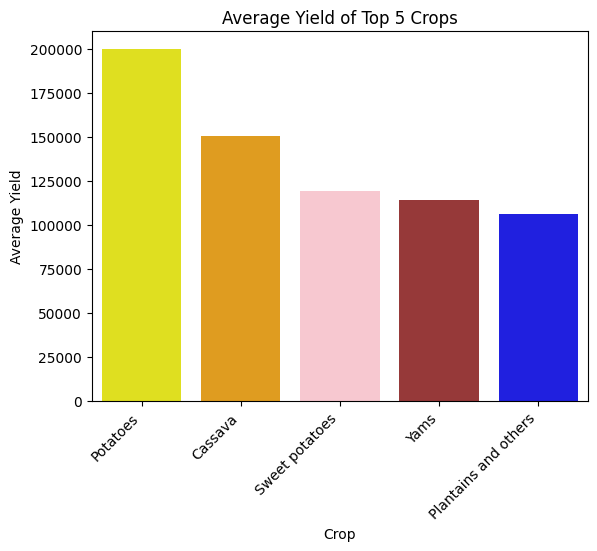

In [19]:
crops=df.groupby('Crop')['hg/ha_yield'].mean().sort_values(ascending=False).head(5)
sns.barplot(x=crops.index,y=crops.values, palette=['yellow','orange','pink','brown','blue'])
plt.title('Average Yield of Top 5 Crops')
plt.xlabel('Crop')
plt.ylabel('Average Yield')
plt.xticks(rotation=45, ha='right')


INSIGHT : Potaoes, Cassava, Sweet potatoes, Yams, Plaintains ad others are observed as the top 5 crops among all. While Sweet potatoes, Yams, Plaintains ad others have the avg yield more than 1,00,000 but the Potatoes are leading with 2,00,000 avg yield

# Correlation between numerical columns

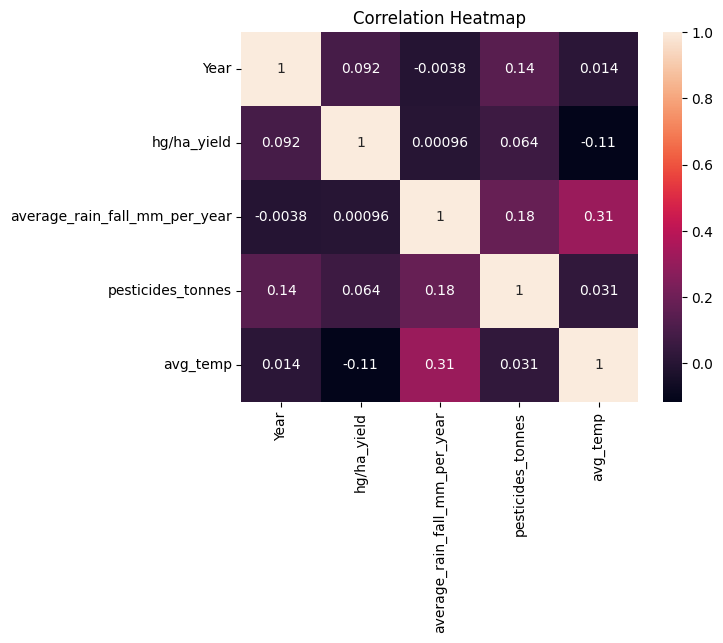

In [20]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

INSIGHT: There appears to be a strong positive correlation between hg/ha_yield (crop yield) and pesticides_tonnes, suggesting that as pesticide usage increases, crop yield tends to increase. There's also a moderate positive correlation between hg/ha_yield and average_rain_fall_mm_per_year. Conversely, the correlation between hg/ha_yield and avg_temp seems to be weak, indicating that average temperature might not be a primary linear driver of overall yield or its effect is more complex than a simple linear relationship. The Year column also shows a positive correlation with hg/ha_yield, which aligns with the previous observation that crop yield has increased over the years.

# Which year had highest average yield?

In [21]:
df.groupby('Year')['hg/ha_yield'].mean().idxmax()

np.int64(2013)

Insight : Year 2013 has the highest average yield compared to all other years in the dataset.

# Which crop is grown in the most countries?

In [22]:
df.groupby('Crop')['Area'].nunique().sort_values(ascending=False)

,Area
Crop,
Potatoes,95
Maize,92
Wheat,82
"Rice, paddy",68
Sorghum,67
Soybeans,58
Sweet potatoes,53
Cassava,41
Plantains and others,21


INSIGHT : Potatoes are grown in over 90 Areas making it the the most famous grown crop all over the world according to the dataset.

**Advanced EDA**

# Which crop has the MOST unstable yield over years?

In [24]:
df.groupby('Crop')['hg/ha_yield'].std().sort_values(ascending=False)

,hg/ha_yield
Crop,
Potatoes,93382.176418
Cassava,89738.515066
Plantains and others,72127.982728
Sweet potatoes,69847.566716
Yams,54211.780054
Maize,27456.370877
"Rice, paddy",19169.699131
Wheat,18387.878272
Sorghum,15117.997174


INSIGHT : Potatoes have the most unstable yield over the years, with a standard deviation of approximately 93,382. This is followed by Cassava (approx. 89,738) and Plantains and others (approx. 72,127). Soybeans show the most stable yield with the lowest standard deviation of approximately 7,603.

# Which country has the most stable yield?

In [25]:
df.groupby('Area')['hg/ha_yield'].std().sort_values().head(1)

,hg/ha_yield
Area,
Botswana,6885.575637


INSIGHT :  Area Botswana has the most satble yield with average yield 6885.57 per year compared to all other countries.

#Which crop performs best in HIGH rainfall conditions?

In [26]:
best=df[df['average_rain_fall_mm_per_year']>df['average_rain_fall_mm_per_year'].mean()]

best.groupby('Crop')['hg/ha_yield'].mean().sort_values(ascending=False)

,hg/ha_yield
Crop,
Potatoes,191089.393531
Yams,116938.577869
Cassava,111402.521779
Sweet potatoes,105488.838762
Plantains and others,105273.461538
"Rice, paddy",38637.390081
Maize,30348.265625
Wheat,29254.264014
Sorghum,17646.784292


INSIGHT: Potatoes perform best in high rainfall conditions with an average yield of approximately 191,089 hg/ha. They are followed by Yams (approx. 116,938 hg/ha) and Cassava (approx. 111,402 hg/ha). Soybeans and Sorghum show the lowest yields in these conditions, around 17,332 hg/ha and 17,646 hg/ha respectively.

#Which crops are grown in the hottest temperatures?

In [27]:
df.groupby('Crop')['avg_temp'].mean().sort_values(ascending=False)

,avg_temp
Crop,
Plantains and others,24.243543
Cassava,24.205756
Yams,22.695726
Sweet potatoes,22.178668
Sorghum,21.431586
"Rice, paddy",21.265378
Maize,19.925159
Soybeans,19.660279
Potatoes,19.007725


INSIGHT: Plantains and others, along with Cassava, are grown in the hottest average temperatures, both averaging around 24.2 degrees Celsius. Yams and Sweet potatoes also thrive in relatively hot conditions, with average temperatures above 22 degrees Celsius. Wheat is grown in the coolest average temperatures among the listed crops.

# Top 5 countries with highest pesticide usage

In [28]:
df.groupby('Area')['pesticides_tonnes'].mean().sort_values(ascending=False)

,pesticides_tonnes
Area,
Brazil,189736.869565
France,85238.429565
Italy,80175.895652
Japan,70285.467391
Argentina,67929.460000
...,...
Eritrea,22.354500
Mali,21.074348
Central African Republic,18.008261


NSIGHT: Brazil shows the highest pesticide usage, significantly more than other countries, followed by France and Italy. Conversely, countries like Bahrain, Botswana, and Central African Republic have the lowest average pesticide usage.

# Is yield increasing over years globally?

Text(0.5, 1.0, 'Global Yield Over Years')

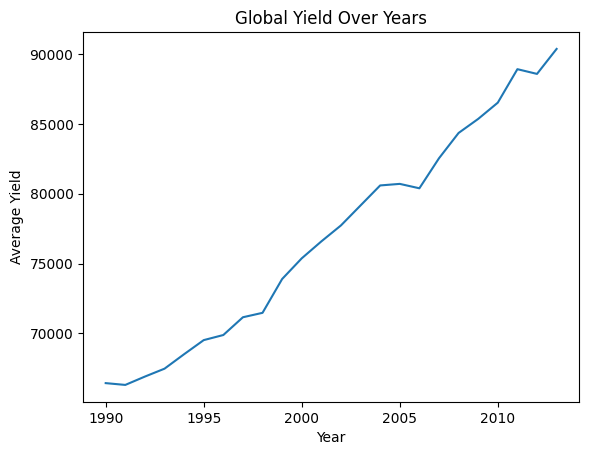

In [29]:
global_yield=df.groupby('Year')['hg/ha_yield'].mean().sort_values()

sns.lineplot(x=global_yield.index, y=global_yield.values)
plt.xlabel('Year')
plt.ylabel('Average Yield')
plt.title('Global Yield Over Years')

INSIGHT : The global yield is consistently increaing over years.
While the growth from years 1995 to 2000 seems consistent but from years 2002 to 2013 the growth has been rapidly increased

# Which crops have the strongest relationship with temperature?

In [30]:
for crop in df['Crop'].unique():
  crop_df=df[df['Crop']== crop]

  corr=crop_df['avg_temp'].corr(crop_df['hg/ha_yield'])
  print(crop,corr)


Maize -0.5452999948606317
Potatoes -0.3728834223245409
Rice, paddy -0.38868664338247183
Sorghum -0.42673211600333427
Soybeans -0.40704362776742165
Wheat -0.3749828128786555
Cassava 0.35404959234685435
Sweet potatoes -0.4066194871366961
Plantains and others -0.06606405116464352
Yams -0.5258032639860033


INSIGHT : Maize shows the strongest negative relationship with temperature, with a correlation coefficient of approximately -0.545. This suggests that as the average temperature increases, the yield of Maize tends to decrease. Yams also show a strong negative relationship (approx. -0.526). On the other hand, Plantains and others have the weakest relationship, with a correlation coefficient close to zero (approx. -0.066). Cassava shows a positive, but weaker, correlation (approx. 0.354), indicating that its yield tends to increase with temperature.

#Which country has the highest average rainfall?

In [31]:
df.groupby('Area')['average_rain_fall_mm_per_year'].mean().sort_values(ascending=False).head()

,average_rain_fall_mm_per_year
Area,
Colombia,3240.0
Papua New Guinea,3142.0
Malaysia,2875.0
Indonesia,2702.0
Bangladesh,2666.0


INSIGHT : Colombia is observed to have the most rainfalls with average rainfall per year 3240.

# Compare yield distributions of top 5 crops

In [32]:
df.groupby('Crop')['hg/ha_yield'].mean().sort_values(ascending=False).head()
# this gives highest avg yeild but we need the distribution

,hg/ha_yield
Crop,
Potatoes,199801.549579
Cassava,150479.466993
Sweet potatoes,119057.793772
Yams,114140.345927
Plantains and others,106041.320144


<Axes: xlabel='Crop', ylabel='hg/ha_yield'>

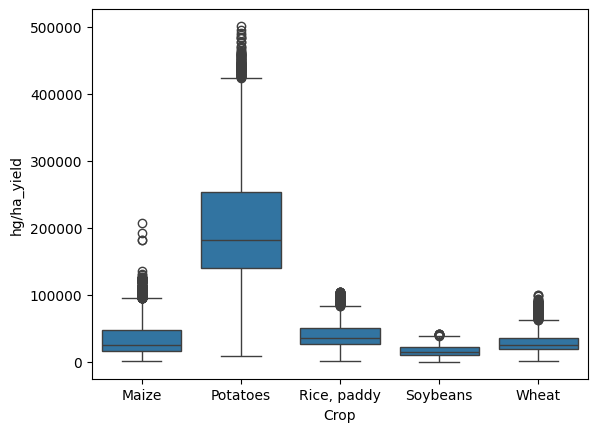

In [33]:
top_crops=df["Crop"].value_counts().head(5).index
filtered_df=df[df['Crop'].isin(top_crops)]
sns.boxplot(
    x='Crop',
    y='hg/ha_yield',
    data=filtered_df
)

INSIGHT: Potatoes consistently exhibit the highest average yield, and their distribution appears to be the widest, suggesting significant variability in yield (which aligns with being the most unstable crop). Cassava and Sweet potatoes follow with high average yields, while Yams and Plantains and others have slightly lower, but still substantial, average yields. The boxplot would visually represent these differences in central tendency (median) and spread (interquartile range and whiskers) for each of these top-performing crops, likely showing Potatoes with the highest median and largest range, indicating both its high potential and its considerable variability.

# Which years had unusually high yields?

In [34]:
yearly = df.groupby('Year')['hg/ha_yield'].mean()

yearly[yearly > yearly.mean()]

,hg/ha_yield
Year,
2002,77730.135993
2004,80590.019449
2005,80702.022672
2006,80386.269509
2007,82532.894525
2008,84344.385048
2009,85350.016908
2010,86512.526104
2011,88908.335743


In [35]:
yearly.mean()

np.float64(76937.90008575129)

INSIGHT : The Year 2013 has the highest hg/ha yield compared to the other years. Years 2002,2004,2005,2006,2007,2008,2009,2010,2011,2012 have hg/ha yield more than the avrage yeild of the total dataset

In [36]:
df.to_csv('crop_cleaned.csv' , index=False)
# downloading the cleaned dataset to continue getting insights through SQL
